# Test PathFinder with simulated data

Generate random data with known rank and test Pathfinder's ability to reconstruct the data.


In [1]:
from pathfinder import decomp, utils

# -- here while dev in progress
import importlib
importlib.reload(utils)
importlib.reload(decomp)
# ---


<module 'pathfinder.decomp' from '/opt/miniconda3/envs/py38/lib/python3.8/site-packages/pathfinder/decomp.py'>

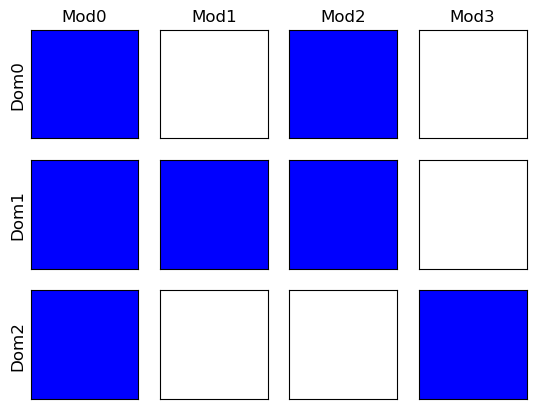

In [2]:
# simulate data
data_dict, data_complete = utils.simulate_data_grid(num_domains=3, 
                                                    num_modalities=4, 
                                                    missing=[(0,1),(0,3),(1,3),(2,1),(2,2)],
                                                    output_complete=True)

# visualise data organisation
_ = utils.plot_data_grid(data_dict)


In [14]:

# Fit the data
from sklearn.linear_model import Ridge
algo = decomp.JointOuterDecomp(n_components=5, n_iter=30, dropout=-1,
                               method=Ridge, method_kwargs={'alpha':1e2, 'positive':True})

algo.fit(data_dict)


100%|███████████████████████████████████████████| 30/30 [00:38<00:00,  1.30s/it]


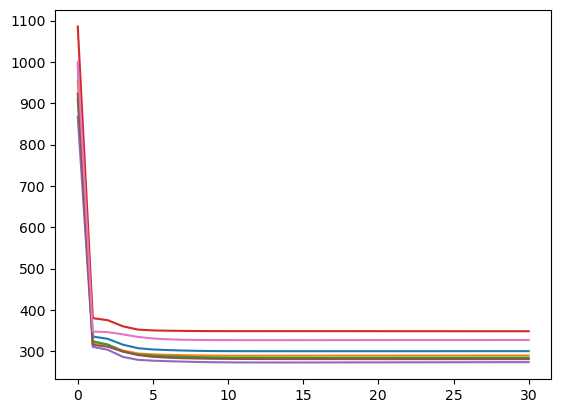

In [15]:
# Plot error
import matplotlib.pyplot as plt
_ = plt.plot(algo._loss)



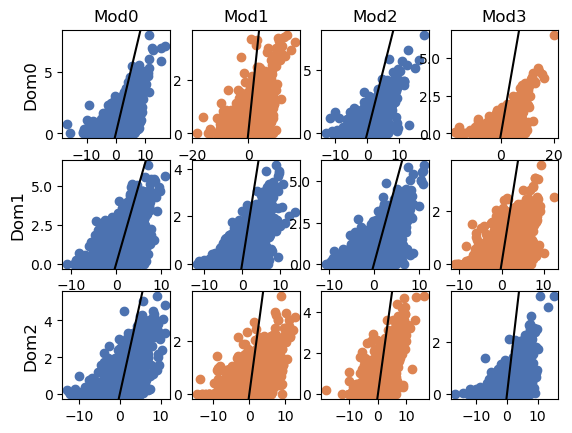

In [16]:
# Plot data and fit
data_pred = algo.predict(as_dict=True)
for i, d in enumerate(data_pred):
    for j, m in enumerate(data_pred[d]):
        if data_pred[d][m] is None:
            data_pred[d][m] = algo._A[i]@algo._S[j].T

_ = utils.plot_data_fit(data_dict, data_pred, data_complete)
